# SHAP Explainer for Cloud Model

This notebook explains **cloud model predictions** using **SHAP**.

Pipeline:
1. Load trained cloud model and artifacts
2. Load normalization config and feature list
3. Prepare one input row
4. Normalize features
5. Rename feature names to safe names for XGBoost
6. Predict risk
7. Compute SHAP values
8. Show top contributing features
9. Plot SHAP waterfall / bar chart


In [4]:
import sys
print(sys.executable)
!{sys.executable} -m pip install shap

c:\Users\Zhanel\AppData\Local\Programs\Python\Python311\python.exe



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from preprocess import normalize_features


In [6]:
ARTIFACTS_DIR = Path("training/artifacts")

MODEL_PATH = ARTIFACTS_DIR / "cloud_model.pkl"
FEATURES_PATH = ARTIFACTS_DIR / "cloud_feature_list.json"
NORMALIZATION_CONFIG_PATH = ARTIFACTS_DIR / "cloud_normalization_config.json"


In [7]:
def load_json(path: str | Path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def sanitize_feature_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        col.replace("[", "")
           .replace("]", "")
           .replace("<", "")
           .replace(" ", "_")
        for col in df.columns
    ]
    return df


def load_cloud_artifacts():
    model = joblib.load(MODEL_PATH)
    feature_list = load_json(FEATURES_PATH)
    normalization_config = load_json(NORMALIZATION_CONFIG_PATH)
    return model, feature_list, normalization_config


In [8]:
def prepare_cloud_input(input_df: pd.DataFrame) -> pd.DataFrame:
    model, feature_list, normalization_config = load_cloud_artifacts()

    df = input_df.copy()

    missing = [col for col in feature_list if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required features: {missing}")

    df = df[feature_list].copy()
    df = normalize_features(df, normalization_config)
    df = sanitize_feature_names(df)

    return df


In [9]:
def explain_cloud_prediction(input_df: pd.DataFrame, top_n: int = 3) -> tuple[dict, pd.DataFrame]:
    model, feature_list, normalization_config = load_cloud_artifacts()

    X = prepare_cloud_input(input_df)

    if len(X) != 1:
        raise ValueError("Please pass exactly one row for local SHAP explanation.")

    prediction = int(model.predict(X)[0])

    probability = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.shape[1] >= 2:
            probability = float(proba[0][1])
        else:
            probability = float(proba[0][0])

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        row_shap = shap_values[1][0] if len(shap_values) > 1 else shap_values[0][0]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        if len(getattr(shap_values, "shape", [])) == 3:
            row_shap = shap_values[0, :, 1]
            base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value
        else:
            row_shap = shap_values[0]
            base_value = explainer.expected_value

    explanation_df = pd.DataFrame({
        "feature": X.columns,
        "feature_value": X.iloc[0].values,
        "shap_value": row_shap,
    })

    explanation_df["abs_shap"] = explanation_df["shap_value"].abs()
    explanation_df = explanation_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    result = {
        "prediction": prediction,
        "probability": probability,
        "top_factors": explanation_df.head(top_n)[["feature", "feature_value", "shap_value"]].to_dict(orient="records"),
        "base_value": float(base_value) if np.isscalar(base_value) else float(np.array(base_value).reshape(-1)[0]),
    }

    return result, explanation_df


In [10]:
# Example raw input row
raw_row = {
    "Air temperature [K]": 298.4,
    "Process temperature [K]": 308.9,
    "Rotational speed [rpm]": 1450.0,
    "Torque [Nm]": 52.0,
    "Tool wear [min]": 180.0,
}

row_df = pd.DataFrame([raw_row])

# Create engineered features exactly like in preprocessing
row_df["temp_diff"] = row_df["Process temperature [K]"] - row_df["Air temperature [K]"]
row_df["power_kw"] = (
    2 * np.pi * row_df["Torque [Nm]"] * row_df["Rotational speed [rpm]"] / 60.0 / 1000.0
)

cloud_input = row_df[[
    "Air temperature [K]",
    "temp_diff",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "power_kw",
    "Tool wear [min]",
]]

cloud_input


,Air temperature [K],temp_diff,Rotational speed [rpm],Torque [Nm],power_kw,Tool wear [min]
0,298.4,10.5,1450.0,52.0,7.89587,180.0


In [11]:
result, explanation_df = explain_cloud_prediction(cloud_input, top_n=3)

print("Prediction:", result["prediction"])
print("Probability:", result["probability"])
print("\nTop factors:")
pd.DataFrame(result["top_factors"])


Prediction: 0
Probability: 0.028957238420844078

Top factors:


,feature,feature_value,shap_value
0,Rotational_speed_rpm,0.775816,-1.339897
1,Tool_wear_min,0.873786,-0.916056
2,temp_diff,0.700000,-0.652062


In [12]:
explanation_df


,feature,feature_value,shap_value,abs_shap
0,Rotational_speed_rpm,0.775816,-1.339897,1.339897
1,Tool_wear_min,0.873786,-0.916056,0.916056
2,temp_diff,0.700000,-0.652062,0.652062
3,Torque_Nm,0.923623,-0.379780,0.379780
4,power_kw,0.981512,-0.138540,0.138540
5,Air_temperature_K,0.203125,-0.082564,0.082564


In [13]:
# Alert example
risk_score = result["probability"]

if risk_score is not None and risk_score >= 0.8:
    top_features = [item["feature"] for item in result["top_factors"]]
    alert = {
        "severity": "high",
        "prediction": result["prediction"],
        "risk_score": risk_score,
        "top_features": top_features,
        "message": f"High risk detected. Main factors: {', '.join(top_features)}"
    }
    print(alert)
else:
    print("No high-risk alert triggered.")


No high-risk alert triggered.


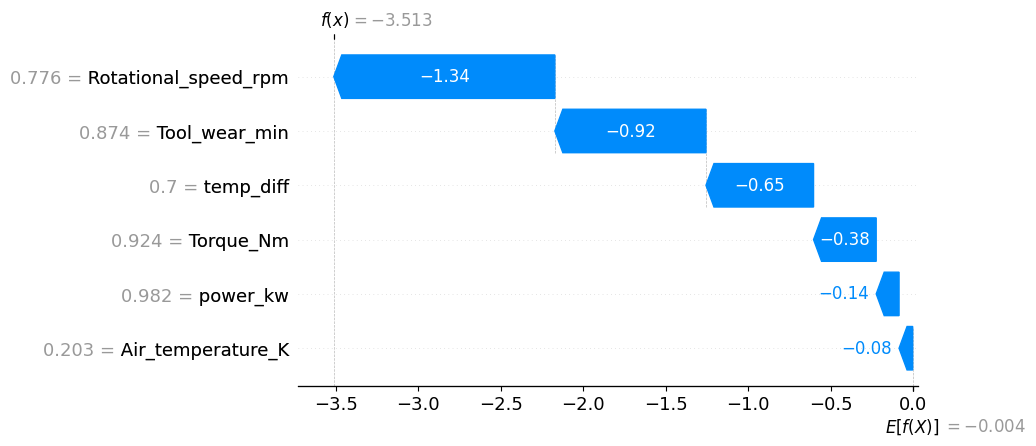

In [14]:
# SHAP plot
model, _, _ = load_cloud_artifacts()
X = prepare_cloud_input(cloud_input)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    values_to_plot = shap_values[1][0] if len(shap_values) > 1 else shap_values[0][0]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) and len(explainer.expected_value) > 1 else explainer.expected_value[0]
else:
    if len(getattr(shap_values, "shape", [])) == 3:
        values_to_plot = shap_values[0, :, 1]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value
    else:
        values_to_plot = shap_values[0]
        base_value = explainer.expected_value

shap_exp = shap.Explanation(
    values=values_to_plot,
    base_values=base_value,
    data=X.iloc[0].values,
    feature_names=X.columns.tolist()
)

shap.plots.waterfall(shap_exp, max_display=6)
plt.show()


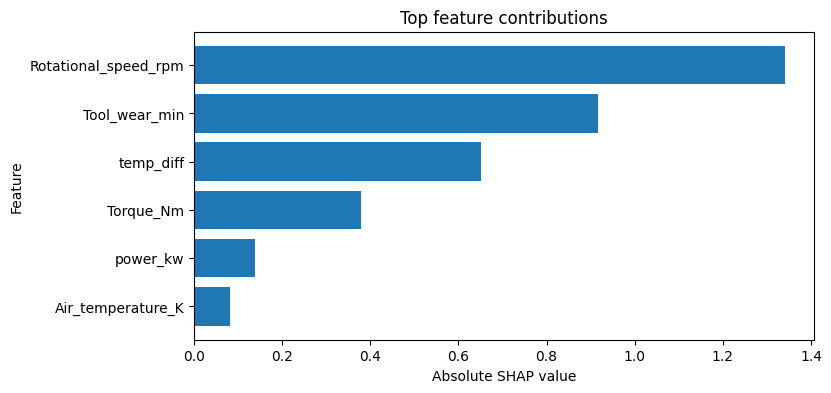

In [15]:
# Simple bar plot of absolute SHAP values
plot_df = explanation_df.copy().sort_values("abs_shap", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["feature"], plot_df["abs_shap"])
plt.xlabel("Absolute SHAP value")
plt.ylabel("Feature")
plt.title("Top feature contributions")
plt.show()


In [16]:
# Optional: save SHAP explanation to JSON
output = {
    "prediction": result["prediction"],
    "probability": result["probability"],
    "top_factors": result["top_factors"],
    "all_factors": explanation_df.drop(columns=["abs_shap"]).to_dict(orient="records"),
}

with open("cloud_shap_explanation_example.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print("Saved to cloud_shap_explanation_example.json")


Saved to cloud_shap_explanation_example.json
